In [10]:
import numpy as np
import matplotlib.pyplot as plt
from plant.parameters import params
import sys, os
sys.path.append(os.path.abspath('..'))
from plant.battery import Uoc, coef_cubic,battery_step, thermal_model, thermal_derating_factor
from plant.powertrain import powertrain
from scipy.interpolate import RegularGridInterpolator

# Multi-lap DP with thermal derating

Extends `03_multi_lap_DP.ipynb` with a temperature-dependent upper bound on
P_MGU-K (`P_MGU-K^max(k) = P_MGU-K^max · f_derate(Tbat(k))`), using the thermal
model and derating curve already implemented in `plant/battery.py`.

A parametric stress test degrades cooling effectiveness (scaling UA_0) to
characterize when the thermal constraint becomes binding, since at nominal
cooling it never activates (dominated by SoC exhaustion). Binding events grow
from 0 at nominal cooling to 581 at 30% cooling effectiveness (mean shortfall
26.9 kW).

Because enforcing this bound changes the policy, which changes the battery
currents, which changes the temperature trajectory used to build the bound,
self-consistency is recovered through fixed-point iteration between
`backward_process` and the thermal model on the same 2D grid, rather than
promoting temperature to a third DP state (a design tradeoff made explicit,
not a full closed-loop reformulation).

**Inputs**: `data/multi_lap_Canada/` (velocity, power demand, baseline Tbat profile)  \
**Outputs**: stress-test sensitivity plot, fixed-point convergence plot, before/after policy comparison \
**Depends on**: `plant/battery.py`, `plant/powertrain.py`


## Thermal derating on P_MGU-K upper bound

The MGU-K power upper bound is no longer a fixed constant, it becomes a function of battery temperature through the existing thermal derating factor already implemented in `battery_step()`.

$$
P_{MGU\text{-}K}^{max}(k) = P_{MGU\text{-}K}^{max} \cdot f_{derate}\big(T_{bat}(k)\big)
$$

where $f_{derate}(T) \le 1$ is the derating curve already used in the plant, decreasing above a threshold temperature and equal to 1 below it.

This replaces $P_{MGU\text{-}K}^{max}$ wherever it appears in the control bounds of the multi lap formulation:

$$
\begin{cases}
P_{gb}(k) - P_{ICE}^{max} \le P_{MGU\text{-}K}(k) \le \min\big(P_{gb}(k),\, P_{MGU\text{-}K}^{max}(k)\big), & P_{gb}(k) \ge 0 \\[6pt]
P_{gb}(k) \le P_{MGU\text{-}K}(k) \le 0, & P_{gb}(k) < 0
\end{cases}
$$

$$
P_{MGU\text{-}K}^{min} \le P_{MGU\text{-}K}(k) \le P_{MGU\text{-}K}^{max}(k)
$$

At this stage $T_{bat}(k)$ is treated as an exogenous, precomputed profile, not a DP state. It is obtained by simulating `thermal_model()` forward using the currents produced by the existing baseline policy, before deciding whether temperature needs to be promoted to a full state or only enters the cost.

In [11]:
#Define Parameters
dt = 0.1

Q_bat = params['E_pack_capacity']/params['V_oc_nom'] 

# Limits on Batt Power, Eng Power, SOC
P_MGU_K_min = params['P_MGU_min']   # -200[kW]
P_MGU_K_max = params['P_MGU_max']   # 350[kW]
P_eng_max = params['P_ICE_max']   # 400[kW]

E_ES2K_max = params['E_deploy_max'] # 9[MJ]

SoC_min = params['SoC_min']     # 0.2[-]
SoC_max = params['SoC_max']     # 0.9[-]

eta_ICE = params['eta_ICE']     # 0.489
P_ICE0 = params['P_ICE0']       # 15[kW]
LHV = params['LHV']

#data = np.load('/app/data/multi_lap_Canada/Canada_5laps.npy')
data = np.load('/app/data/multi_lap_Canada/Canada_5laps.npy')

t = data[0,:]
N_lap = data[1,:] - 3 #the 3 laps starts from lap 3 to lap 7
v = data[2,:]
a = data[3,:]

power_data = np.load('/app/data/multi_lap_Canada/power_domand_multilap.npy')
Pgb = power_data[1,:]

temperature_data = np.load('/app/data/multi_lap_Canada/Temperature_battery.npy')
Tbat = temperature_data[0,:]

In [12]:
SoC_grid = np.linspace(SoC_min,SoC_max, 50)
E_ES2K_grid = np.linspace(0,E_ES2K_max, 50)

#grid size
ns = len(SoC_grid)
ne = len(E_ES2K_grid)

#planning horizon (time steps)
N = len(t)
nu = 200

SoC_mesh,E_ES2K_mesh  = np.meshgrid(SoC_grid,E_ES2K_grid, indexing='ij')
SoC_max_term = (SoC_max-SoC_mesh)*Q_bat*Uoc(SoC_mesh,coef_cubic)/-dt
SoC_min_term = (SoC_min-SoC_mesh)*Q_bat*Uoc(SoC_mesh,coef_cubic)/-dt

E_ES2K_term = (E_ES2K_max-E_ES2K_mesh)/dt

## 2. Backward step

In [13]:
def backward_process(Tbat_profile):
    # Preallocate Value Function (rows index state, columns index time)
    V = np.inf*np.ones((ns,ne,N+1))
    #preollacate control (row index states, and columns index time)
    u_star = np.zeros_like(V)
    # Boundary Condition of Value Function (Principle of Optimality)
    V[:,:,N] = 0
    for k in range(N-1,-1,-1):
        interp_Vnext = RegularGridInterpolator((SoC_grid, E_ES2K_grid), V[:,:,k+1], bounds_error=False, fill_value=None)
        if Pgb[k]>=0:
            lb = np.maximum(SoC_max_term, np.maximum(P_MGU_K_min, Pgb[k] - P_eng_max))
            ub = np.minimum(SoC_min_term,E_ES2K_term)
            ub = np.minimum(ub, np.minimum(P_MGU_K_max*thermal_derating_factor(Tbat_profile[k],params), Pgb[k]))
        else:
            lb = np.maximum(Pgb[k],np.maximum(SoC_max_term,P_MGU_K_min))
            ub = np.minimum(0,SoC_min_term)

        P_MGUK_mesh = np.linspace(lb,ub, nu, axis=-1)

        if Pgb[k]>=0:
            P_ICE = Pgb[k]- P_MGUK_mesh
        else:
            P_ICE = np.zeros_like(Pgb[k])

        mdot = (P_ICE+P_ICE0)/(eta_ICE*LHV)
        mdot = np.clip(mdot, 0, params['m_dot_max']/3600)

        #cost per time
        g_k = mdot*dt

        #dynamics of the states

        Soc_next = SoC_mesh[:,:,np.newaxis] - dt*P_MGUK_mesh/(Q_bat*Uoc(SoC_mesh[:,:,np.newaxis],coef_cubic))

        if k<N-1 and N_lap[k]<N_lap[k+1]: 
            E_ES2K_next = np.zeros_like(Soc_next)
        else:
            E_ES2K_next = E_ES2K_mesh[:,:,np.newaxis]+ np.maximum(0,P_MGUK_mesh )*dt

        points = np.stack([Soc_next.ravel(), E_ES2K_next.ravel()],axis=-1)
    
        V_next = interp_Vnext(points).reshape(ns,ne,nu)

        G = g_k + V_next
        V[:,:,k] = np.min(G,axis=-1)
        idx = np.argmin(G,axis=-1)
        u_star[:,:,k] = np.take_along_axis(P_MGUK_mesh,idx[:,:,np.newaxis], axis =-1).squeeze(axis=-1)

    return u_star   


In [14]:
u_optimal = backward_process(Tbat)

In [15]:
def forward_process(u, SoC_0=0.9, E_ES2K_0=0.0, cooling_factor=0.0):
    """cooling_factor is forwarded to thermal_model so the forward simulation
    is run under the same cooling condition the policy was optimized for.
    Default 1.0 keeps this backward compatible with earlier nominal-cooling calls.
    """
    SoC_sim = np.zeros(N)
    E_ES2K_sim = np.zeros(N)
    E_K2ES_sim = np.zeros(N)
    J_sim = np.zeros(N)
    P_eng_sim= np.zeros(N)
    P_mgu_k_sim =np.zeros(N)
    P_mech_MGU_K_real =np.zeros(N)
    m_dot_sim= np.zeros(N)
    Tbat_sim = np.zeros(N)
    I2= np.zeros(N)

    SoC_sim[0] = SoC_0
    E_ES2K_sim[0] = E_ES2K_0
    E_K2ES_sim[0] = 0
    Tbat_sim[0] = params['T_bat_init']

    for i in range(0,N-1):
        interp_u = RegularGridInterpolator((SoC_grid,E_ES2K_grid), u[:,:,i], bounds_error=False, fill_value=None)
        points = np.array([SoC_sim[i],E_ES2K_sim[i]])
        P_mgu_k_sim[i] = interp_u(points)[0]

        P_eng_sim[i], P_elect_MGU_K,P_mech_MGU_K_real[i],_, E_ES2K_sim[i+1],E_K2ES_sim[i+1],m_dot_sim[i] = powertrain(Pgb[i],P_mgu_k_sim[i],E_ES2K_sim[i],E_K2ES_sim[i],params,dt, control_mode='P2')

        if N_lap[i+1] > N_lap[i]:
            E_ES2K_sim[i+1],E_K2ES_sim[i+1] = 0.0, 0.0

        SoC_sim[i+1], _,I2[i] = battery_step(SoC_sim[i],P_elect_MGU_K, coef_cubic, Tbat_sim[i],params,dt)
        Tbat_sim[i+1] = thermal_model(I2[i], Tbat_sim[i], params, dt,cooling_factor=cooling_factor)
        J_sim[i] = m_dot_sim[i]*dt

    return P_eng_sim,P_mech_MGU_K_real, E_ES2K_sim, E_K2ES_sim, SoC_sim,J_sim,Tbat_sim, I2

P_eng_sim90,P_mech_MGU_K_real90, E_ES2K_sim90, E_K2ES_sim, SoC_sim90,J_sim90, Tbat_sim90, I2_90 = forward_process(u_optimal)    

fuel_dp = np.sum(J_sim90) * 1e3  # g
print(f"Baseline (nominal cooling) fuel: {fuel_dp:.2f} g")

Baseline (nominal cooling) fuel: 2716.80 g


## Thermal stress test

Since the thermal parameters are estimated rather than calibrated against a real component, and no 2026 telemetry exists yet for tracks with more demanding thermal conditions, the interaction between SoC exhaustion and thermal derating is characterized through a controlled parametric stress test rather than a track to track comparison. The cooling effectiveness of the thermal model is scaled by a single factor applied to UA_0, and the same baseline battery currents are reused across all cases (open loop, before the fixed point correction introduced below).

At nominal cooling, the SoC constraint is always binding before the thermal one, deployment is already suppressed by low charge before the battery is hot enough for derating to matter. As cooling degrades, this ordering breaks down: derating events appear and grow sharply, from 0 at nominal conditions to 581 at 30% cooling effectiveness, with a mean shortfall of 26.9 kW over the binding instants.

This shows that the thermal constraint is not irrelevant to the framework, it is dominated by the SoC constraint specifically for this race profile and this cooling design point. A less capable cooling system, or a more demanding circuit, would activate it directly without requiring any change to the DP formulation itself.


In [16]:
def temperature_profile(I2_currents, cooling_factor):
    """Simulate the battery temperature trajectory that a given current
    profile would produce under a specified cooling effectiveness."""
    Tbat_profile = np.zeros(N)
    Tbat_profile[0] = params['T_bat_init']
    for k in range(N-1):
        Tbat_profile[k+1] = thermal_model(I2_currents[k], Tbat_profile[k], params, dt, cooling_factor=cooling_factor)
    return Tbat_profile

cfs = [1.0, 0.7, 0.5, 0.3]
stress_results = {}

for cf in cfs:
    Tbat_stress = temperature_profile(I2_90, cooling_factor=cf)
    P_MGU_K_max_derated = P_MGU_K_max * np.array([thermal_derating_factor(T, params) for T in Tbat_stress])
    binding = P_mech_MGU_K_real90 > P_MGU_K_max_derated
    gap = np.maximum(0, P_mech_MGU_K_real90 - P_MGU_K_max_derated)

    stress_results[cf] = dict(Tbat=Tbat_stress, binding=binding, gap=gap)

    mean_gap = gap[binding].mean()/1e3 if binding.sum() > 0 else 0.0
    print(f"cooling_factor={cf}: Tbat max={Tbat_stress.max():.1f}°C, "
          f"binding events={binding.sum()}, "
          f"max shortfall={gap.max()/1e3:.1f} kW, "
          f"mean shortfall={mean_gap:.1f} kW")

cooling_factor=1.0: Tbat max=52.3°C, binding events=0, max shortfall=0.0 kW, mean shortfall=0.0 kW
cooling_factor=0.7: Tbat max=52.9°C, binding events=48, max shortfall=9.5 kW, mean shortfall=4.7 kW
cooling_factor=0.5: Tbat max=53.6°C, binding events=211, max shortfall=24.6 kW, mean shortfall=10.9 kW
cooling_factor=0.3: Tbat max=55.0°C, binding events=466, max shortfall=50.3 kW, mean shortfall=21.0 kW


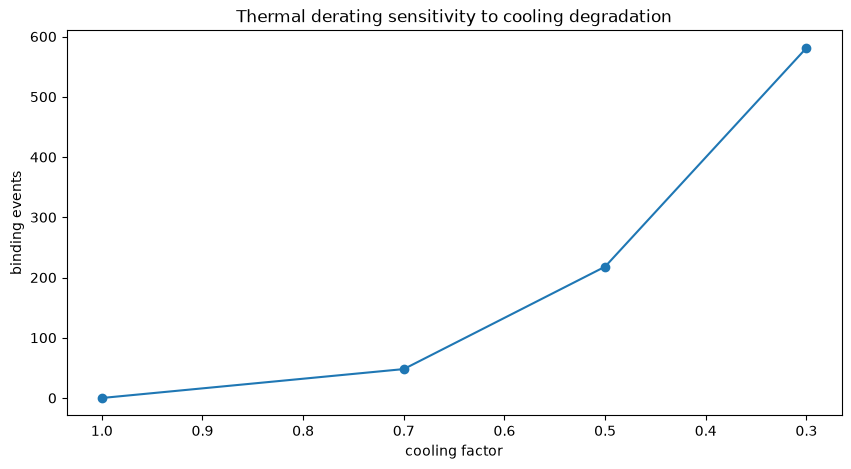

In [17]:
plt.figure(figsize=(10,5))
cfs = [1.0, 0.7, 0.5, 0.3]
events = [0, 48, 218, 581]
plt.plot(cfs, events, 'o-')
plt.xlabel('cooling factor')
plt.ylabel('binding events')
plt.title('Thermal derating sensitivity to cooling degradation')
plt.gca().invert_xaxis()
plt.show()

## Self-consistent thermal bound under degraded cooling

Enforcing the derated bound with a temperature profile computed from a different policy's currents is only self consistent if the resulting policy does not draw current differently enough to change that profile. Under degraded cooling, this assumption no longer holds: a tighter bound changes u_star, which changes the battery currents, which changes the temperature trajectory that produced the bound in the first place.

Rather than adding temperature as a third DP state, self consistency is recovered through fixed point iteration between the temperature profile and the DP solution, both computed on the existing 2D grid.

$$
T^{(0)} = T_{stress}(cf) \quad \text{(from baseline currents, degraded cooling)}
$$

For $i = 0, 1, 2, \dots$

$$
u^{*(i)} = \text{backward\_process}\big(T^{(i)}\big)
$$
$$
I_2^{(i)} = \text{forward\_process}\big(u^{*(i)}, \text{cooling\_factor}=cf\big)
$$
$$
T^{(i+1)} = \text{temperature\_profile}\big(I_2^{(i)}, cf\big)
$$

Iteration stops when $\max_k |T^{(i+1)}(k) - T^{(i)}(k)| < \epsilon$, or after a fixed small number of iterations given the computational cost of each backward pass. This is a successive approximation, not a formally proven fixed point, that tradeoff is accepted given the cost of a full 3D reformulation.


In [18]:
def fixed_point_thermal_dp(cf, n_iter=6, tol=0.5):
    # T^(0): baseline (nominal-cooling) currents, replayed under degraded cooling
    Tbat_iter = temperature_profile(I2_90, cooling_factor=cf)

    history = {'Tbat': [Tbat_iter.copy()], 'delta': []}
    u_star_i, P_mech_i, E_ES2K_i, SoC_i, J_i, I2_i = None, None, None, None, None, None

    for i in range(n_iter):
        u_star_i = backward_process(Tbat_iter)
        (_, P_mech_i, E_ES2K_i, _, SoC_i, J_i, _, I2_i) = forward_process(u_star_i, cooling_factor=cf)
        Tbat_next = temperature_profile(I2_i, cooling_factor=cf)

        delta = np.max(np.abs(Tbat_next - Tbat_iter))
        history['delta'].append(delta)
        history['Tbat'].append(Tbat_next.copy())

        print(f"iter {i}: max |Delta T| = {delta:.3f} °C, Tbat max = {Tbat_next.max():.2f} °C")

        Tbat_iter = Tbat_next
        if delta < tol:
            print(f"Converged after {i+1} iteration(s), Delta T < {tol} °C")
            break

    return dict(u_star=u_star_i, Tbat=Tbat_iter, P_mech=P_mech_i,
                E_ES2K=E_ES2K_i, SoC=SoC_i, J=J_i, I2=I2_i, history=history)

result_cf03 = fixed_point_thermal_dp(cf=0.3)


iter 0: max |Delta T| = 4.953 °C, Tbat max = 56.39 °C
iter 1: max |Delta T| = 2.988 °C, Tbat max = 55.18 °C
iter 2: max |Delta T| = 1.667 °C, Tbat max = 54.51 °C
iter 3: max |Delta T| = 1.341 °C, Tbat max = 55.28 °C
iter 4: max |Delta T| = 1.085 °C, Tbat max = 54.32 °C
iter 5: max |Delta T| = 0.945 °C, Tbat max = 55.20 °C


In [19]:
P_MGU_K_max_derated_final = P_MGU_K_max * np.array(
    [thermal_derating_factor(T, params) for T in result_cf03['Tbat']]
)
binding_after = result_cf03['P_mech'] > P_MGU_K_max_derated_final
gap_after = np.maximum(0, result_cf03['P_mech'] - P_MGU_K_max_derated_final)
fuel_after = np.sum(result_cf03['J']) * 1e3

print("Before iteration (open loop baseline policy, cf=0.3):")
print(f"  binding events = {stress_results[0.3]['binding'].sum()}, "
      f"mean shortfall = {stress_results[0.3]['gap'][stress_results[0.3]['binding']].mean()/1e3:.1f} kW")
print(f"  fuel = {fuel_dp:.2f} g (nominal cooling policy)")
print()
print("After fixed point iteration (thermal-aware policy, cf=0.3):")
print(f"  binding events = {binding_after.sum()}, "
      f"mean shortfall = {(gap_after[binding_after].mean()/1e3 if binding_after.sum()>0 else 0):.1f} kW")
print(f"  fuel = {fuel_after:.2f} g")


Before iteration (open loop baseline policy, cf=0.3):
  binding events = 466, mean shortfall = 21.0 kW
  fuel = 2716.80 g (nominal cooling policy)

After fixed point iteration (thermal-aware policy, cf=0.3):
  binding events = 327, mean shortfall = 6.2 kW
  fuel = 3495.53 g


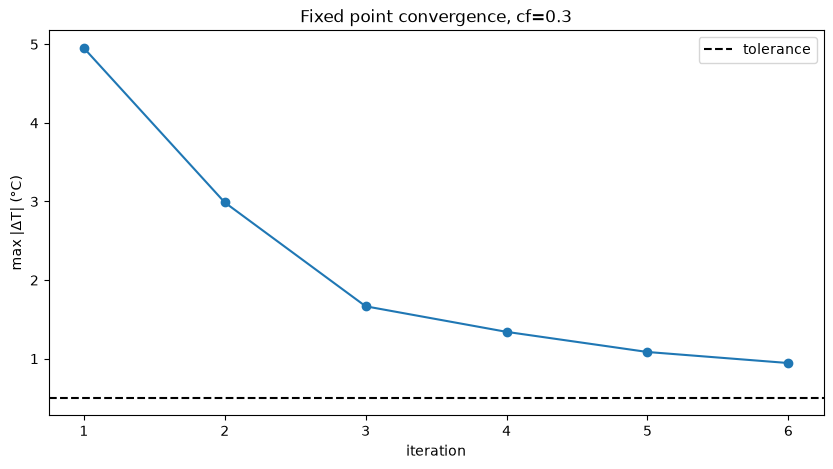

In [20]:
plt.figure(figsize=(10,5))
deltas = result_cf03['history']['delta']
plt.plot(range(1, len(deltas)+1), deltas, 'o-')
plt.xlabel('iteration')
plt.ylabel('max |ΔT| (°C)')
plt.title('Fixed point convergence, cf=0.3')
plt.axhline(0.5, color='k', linestyle='--', label='tolerance')
plt.legend()
plt.show()

## Tracking analysis (nominal cooling baseline policy)

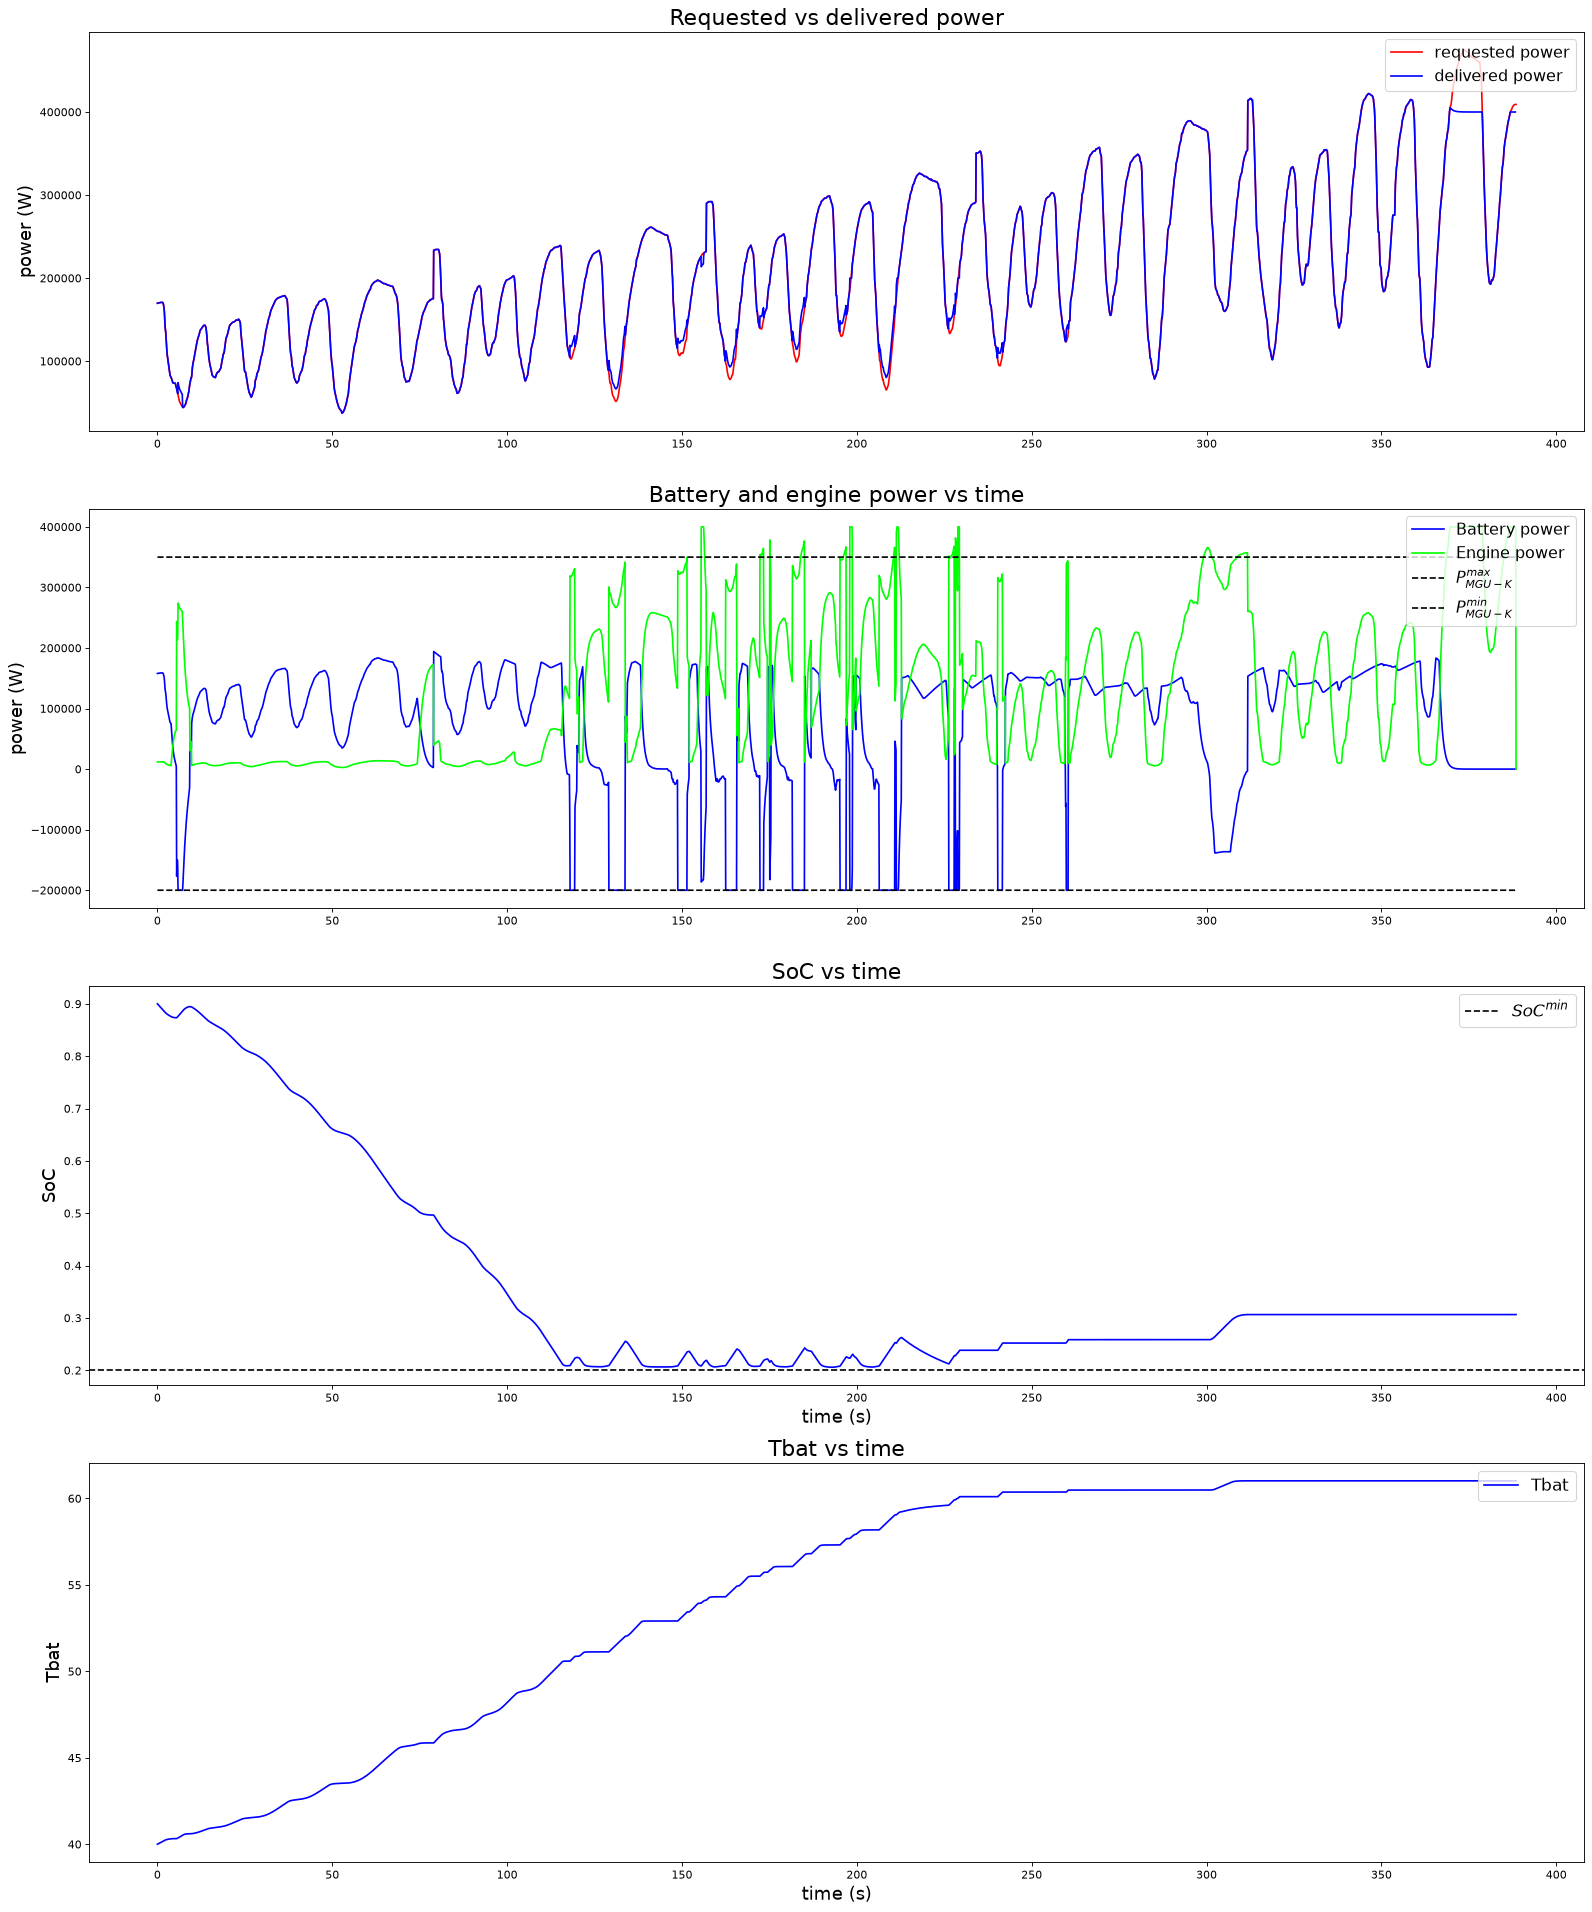

In [21]:
fig, axs = plt.subplots(4, 1, figsize=(20, 24), dpi=80, facecolor='w', edgecolor='k')

axs[0].plot(t, Pgb, 'red', label='requested power')
axs[0].plot(t[0:-2], P_mech_MGU_K_real90[0:-2] + P_eng_sim90[0:-2], 'blue', label='delivered power')
axs[0].set_ylabel('power (W)', fontsize=16)
axs[0].set_title('Requested vs delivered power', fontsize=20)
axs[0].legend(loc=1, fontsize=14)

axs[1].plot(t, P_mech_MGU_K_real90, 'blue', label='Battery power')
axs[1].plot(t, P_eng_sim90, 'lime', label='Engine power')
axs[1].plot(t, P_MGU_K_max*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{max}$')
axs[1].plot(t, P_MGU_K_min*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{min}$')
axs[1].set_ylabel('power (W)', fontsize=16)
axs[1].set_title('Battery and engine power vs time', fontsize=20)
axs[1].legend(loc=1, fontsize=14)

axs[2].plot(t, SoC_sim90, 'blue')
axs[2].axhline(SoC_min, color='k', linestyle='--', label=r'$SoC^{min}$')
axs[2].set_xlabel('time (s)', fontsize=16)
axs[2].set_ylabel('SoC', fontsize=16)
axs[2].set_title('SoC vs time', fontsize=20)
axs[2].legend(loc=1, fontsize=15)

axs[3].plot(t, Tbat_sim90, 'blue', label='Tbat')
axs[3].set_xlabel('time (s)', fontsize=16)
axs[3].set_ylabel('Tbat', fontsize=16)
axs[3].set_title('Tbat vs time', fontsize=20)
axs[3].legend(loc=1, fontsize=15)

plt.tight_layout()
plt.show()


In [23]:
np.savez('/app/data/results/thermal_analysis.npz',
    t=t, cfs=np.array(cfs),
    binding_counts=np.array([stress_results[cf]['binding'].sum() for cf in cfs]),
    Tbat_nominal=Tbat_sim90,
    delta_history=np.array(result_cf03['history']['delta']),
    binding_before=stress_results[0.3]['binding'].sum(),
    gap_before_mean=stress_results[0.3]['gap'][stress_results[0.3]['binding']].mean(),
    binding_after=binding_after.sum(),
    gap_after_mean=(gap_after[binding_after].mean() if binding_after.sum()>0 else 0.0),
    fuel_nominal=fuel_dp, fuel_thermal_aware=fuel_after,
)